In [43]:
import os
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    brier_score_loss,
    roc_curve,
    precision_recall_curve
)

from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier

# ANN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# SHAP
import shap


In [44]:
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

DATA_PATH = "/Users/kratikaneekhra_01/Documents/Smart Health Monitoring /Dataset/heart.csv"

OUTPUT_DIR = "research_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TEST_SIZE = 0.20

In [45]:
print("\n" + "=" * 70)
print("LOADING DATASET")
print("=" * 70)

df = pd.read_csv(DATA_PATH)

print("\nDataset shape:")
print(df.shape)

print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())


LOADING DATASET

Dataset shape:
(918, 12)

First 5 rows:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

Data types:
Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
Fastin

In [46]:
pip install shap;

Note: you may need to restart the kernel to use updated packages.


In [47]:
%pip install numpy pandas matplotlib seaborn scikit-learn joblib xgboost tensorflow

Note: you may need to restart the kernel to use updated packages.


In [48]:
print("\n" + "=" * 70)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 70)

print("\nStatistical summary:")
print(df.describe(include="all").T)

print("\nUnique values:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

TARGET = "HeartDisease"

print("\nTarget distribution:")
print(df[TARGET].value_counts())

print("\nTarget percentage:")
print(df[TARGET].value_counts(normalize=True) * 100)


EXPLORATORY DATA ANALYSIS

Statistical summary:
                count unique     top freq        mean         std   min  \
Age             918.0    NaN     NaN  NaN   53.510893    9.432617  28.0   
Sex               918      2       M  725         NaN         NaN   NaN   
ChestPainType     918      4     ASY  496         NaN         NaN   NaN   
RestingBP       918.0    NaN     NaN  NaN  132.396514   18.514154   0.0   
Cholesterol     918.0    NaN     NaN  NaN  198.799564  109.384145   0.0   
FastingBS       918.0    NaN     NaN  NaN    0.233115    0.423046   0.0   
RestingECG        918      3  Normal  552         NaN         NaN   NaN   
MaxHR           918.0    NaN     NaN  NaN  136.809368   25.460334  60.0   
ExerciseAngina    918      2       N  547         NaN         NaN   NaN   
Oldpeak         918.0    NaN     NaN  NaN    0.887364     1.06657  -2.6   
ST_Slope          918      3    Flat  460         NaN         NaN   NaN   
HeartDisease    918.0    NaN     NaN  NaN    0.5533

In [49]:
print("\n" + "=" * 70)
print("DATA QUALITY CHECK")
print("=" * 70)

# Invalid values in the dataset
if "Cholesterol" in df.columns:
    print(
        "\nZero Cholesterol:",
        (df["Cholesterol"] == 0).sum()
    )

if "RestingBP" in df.columns:
    print(
        "Zero RestingBP:",
        (df["RestingBP"] == 0).sum()
    )

# Treat medically implausible zero values as missing
if "Cholesterol" in df.columns:
    df["Cholesterol"] = df["Cholesterol"].replace(0, np.nan)

if "RestingBP" in df.columns:
    df["RestingBP"] = df["RestingBP"].replace(0, np.nan)




DATA QUALITY CHECK

Zero Cholesterol: 172
Zero RestingBP: 1


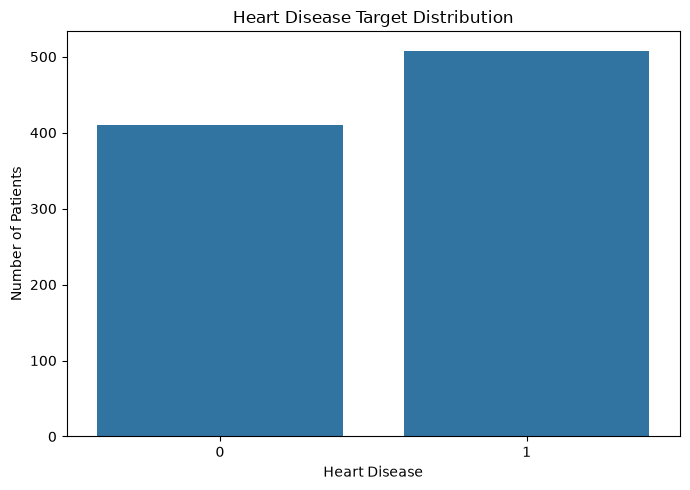

In [50]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x=TARGET
)

plt.title("Heart Disease Target Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.savefig(
    f"{OUTPUT_DIR}/01_target_distribution.png",
    dpi=300
)

plt.show()


In [51]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


Numerical features:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

Categorical features:
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


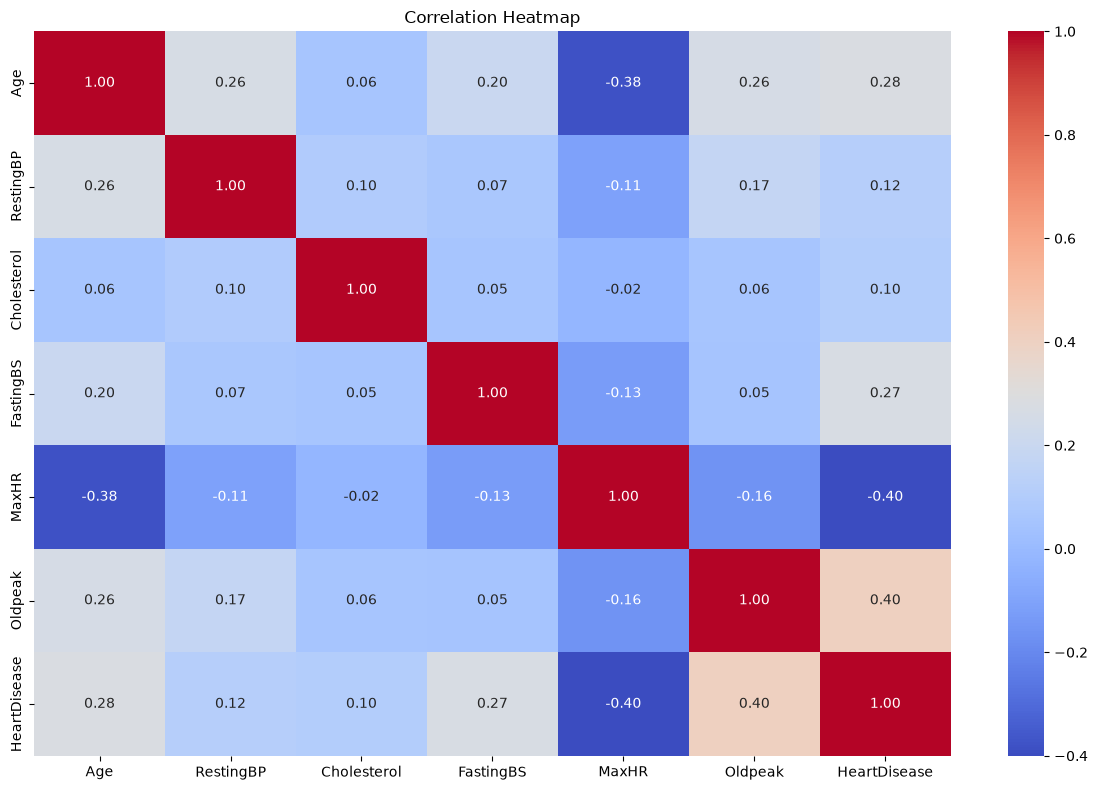

In [52]:
numeric_df = df.select_dtypes(
    include=["int64", "float64"]
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/02_correlation_heatmap.png",
    dpi=300
)

plt.show()


In [53]:
print("\n" + "=" * 70)
print("TRAIN / TEST SPLIT")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print(
    "\nTraining class distribution:"
)

print(
    y_train.value_counts(normalize=True)
)

print(
    "\nTesting class distribution:"
)

print(
    y_test.value_counts(normalize=True)
)



TRAIN / TEST SPLIT
Training samples: 734
Testing samples : 184

Training class distribution:
HeartDisease
1    0.553134
0    0.446866
Name: proportion, dtype: float64

Testing class distribution:
HeartDisease
1    0.554348
0    0.445652
Name: proportion, dtype: float64


In [54]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median") ),
        ("scaler",StandardScaler()  )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ( "imputer", SimpleImputer(strategy="most_frequent"  )
        ),
        ( "encoder", OneHotEncoder( handle_unknown="ignore" )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ( "num", numeric_pipeline, numeric_features),
        (  "cat", categorical_pipeline, categorical_features  )
    ]
)


In [55]:
models = {

    "Logistic Regression":
        LogisticRegression( max_iter=2000, random_state=RANDOM_STATE),

    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE ),

    "Random Forest":RandomForestClassifier( n_estimators=400, random_state=RANDOM_STATE, n_jobs=-1 ),

    "XGBoost":
        XGBClassifier(  n_estimators=300, max_depth=4, learning_rate=0.03,subsample=0.9,colsample_bytree=0.9, eval_metric="logloss",  random_state=RANDOM_STATE,
            n_jobs=-1  )
}



In [70]:
param_grids = {

    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10, 100]
    },

    "Decision Tree": {
        "model__max_depth": [3, 4, 5, 6, 8, 10, None],

        "model__min_samples_split": [2, 5, 10, 20],

        "model__min_samples_leaf": [1, 2, 4, 8],

        "model__criterion": ["gini", "entropy"]
    },

    "Random Forest": {
        "model__n_estimators": [100, 200, 300],

        "model__max_depth": [None, 5, 10, 15, 20],

        "model__min_samples_split": [2, 5, 10],

        "model__min_samples_leaf": [1, 2, 4],

        "model__max_features": ["sqrt", "log2"]
    },

    "XGBoost": {
        "model__n_estimators": [100, 200, 300],

        "model__max_depth": [3, 4, 5, 6],

        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],

        "model__subsample": [0.7, 0.8, 1.0],

        "model__colsample_bytree": [0.7, 0.8, 1.0]
    },

    "ANN": {
        "model__hidden_layer_sizes": [(32,), (64,), (128,), (64, 32)],

        "model__activation": ["relu", "tanh"],

        "model__alpha": [0.0001, 0.001, 0.01],

        "model__learning_rate": ["constant", "adaptive"]
    }
}

In [57]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = []
trained_models = {}



In [58]:
for name, model in models.items():

    print("\n" + "=" * 70)
    print(f"TRAINING: {name}")
    print("=" * 70)

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    start = time.time()

    grid = GridSearchCV(
        pipeline,
        param_grids[name],
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True
    )

    grid.fit(X_train, y_train)

    training_time = time.time() - start

    best_model = grid.best_estimator_

    trained_models[name] = best_model

    print("\nBest parameters:")
    print(grid.best_params_)

    print(
        "\nBest CV ROC-AUC:",
        round(grid.best_score_, 4)
    )

    # Predictions
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    # Metrics
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred
    )

    recall = recall_score(
        y_test,
        y_pred
    )

    f1 = f1_score(
        y_test,
        y_pred
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    pr_auc = average_precision_score(
        y_test,
        y_prob
    )

    specificity = tn / (tn + fp)

    npv = tn / (tn + fn)

    brier = brier_score_loss(
        y_test,
        y_prob
    )

    cv_scores = cross_validate(
        best_model,
        X_train,
        y_train,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc"
        ],
        n_jobs=-1
    )

    result = {

        "Model": name,

        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,

        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,

        "Specificity": specificity,
        "NPV": npv,

        "Brier": brier,

        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,

        "CV_Accuracy": cv_scores[
            "test_accuracy"
        ].mean(),

        "CV_Precision": cv_scores[
            "test_precision"
        ].mean(),

        "CV_Recall": cv_scores[
            "test_recall"
        ].mean(),

        "CV_F1": cv_scores[
            "test_f1"
        ].mean(),

        "CV_ROC_AUC": cv_scores[
            "test_roc_auc"
        ].mean(),

        "CV_ROC_AUC_SD": cv_scores[
            "test_roc_auc"
        ].std(),

        "Training_Time": training_time
    }

    cv_results.append(result)

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    print("\nConfusion Matrix:")
    print(
        confusion_matrix(
            y_test,
            y_pred
        )
    )



TRAINING: Logistic Regression

Best parameters:
{'model__C': 1}

Best CV ROC-AUC: 0.922

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184


Confusion Matrix:
[[70 12]
 [ 9 93]]

TRAINING: Decision Tree

Best parameters:
{'model__max_depth': 3, 'model__min_samples_leaf': 10, 'model__min_samples_split': 2}

Best CV ROC-AUC: 0.9074

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.85      0.81        82
           1       0.87      0.79      0.83       102

    accuracy                           0.82       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.83      0.82      0.82       184


Confusion Matrix

In [ ]:
print("\n" + "=" * 70)
print("TRAINING: ARTIFICIAL NEURAL NETWORK")
print("=" * 70)


# Fit preprocessing ONLY on training data
X_train_processed = preprocessor.fit_transform(
    X_train
)

X_test_processed = preprocessor.transform(
    X_test
)

# Convert sparse matrix if necessary
if hasattr(
    X_train_processed,
    "toarray"
):
    X_train_processed = X_train_processed.toarray()

if hasattr(
    X_test_processed,
    "toarray"
):
    X_test_processed = X_test_processed.toarray()


input_dim = X_train_processed.shape[1]


def build_ann(input_dim):

    model = Sequential([

        Dense( 64,activation="relu", input_shape=(input_dim,)),

        Dropout(0.20),

        Dense( 32, activation="relu"  ),

        Dropout(0.10),

        Dense( 16, activation="relu" ),

        Dense( 1, activation="sigmoid" )
    ])

    model.compile(

        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.001
        ),

        loss="binary_crossentropy",

        metrics=[
            "accuracy",tf.keras.metrics.AUC(name="auc"  )
        ]
    )

    return model


ann = build_ann(input_dim)

early_stop = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=15,
    restore_best_weights=True
)

start = time.time()

history = ann.fit(

    X_train_processed,
    y_train,

    validation_split=0.20,

    epochs=150,

    batch_size=32,

    callbacks=[early_stop],

    verbose=0
)

ann_training_time = time.time() - start


# ANN predictions
ann_prob = ann.predict(
    X_test_processed,
    verbose=0
).ravel()

ann_pred = (
    ann_prob >= 0.5
).astype(int)


tn, fp, fn, tp = confusion_matrix(
    y_test,
    ann_pred
).ravel()


ann_result = {

    "Model": "ANN",

    "Accuracy": accuracy_score(
        y_test,
        ann_pred
    ),

    "Precision": precision_score(
        y_test,
        ann_pred
    ),

    "Recall": recall_score(
        y_test,
        ann_pred
    ),

    "F1": f1_score(
        y_test,
        ann_pred
    ),

    "ROC_AUC": roc_auc_score( y_test, ann_prob),

    "PR_AUC": average_precision_score( y_test, ann_prob ),

    "Specificity":
        tn / (tn + fp),

    "NPV":
        tn / (tn + fn),

    "Brier":
        brier_score_loss(
            y_test,
            ann_prob
        ),

    "TP": tp,
    "TN": tn,
    "FP": fp,
    "FN": fn,

    "Training_Time":
        ann_training_time
}

cv_results.append(
    ann_result
)

trained_models["ANN"] = ann




TRAINING: ARTIFICIAL NEURAL NETWORK


In [60]:
results_df = pd.DataFrame(
    cv_results
)

print("\n" + "=" * 70)
print("FINAL MODEL COMPARISON")
print("=" * 70)

display_columns = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "PR_AUC",
    "Specificity",
    "NPV",
    "Brier"
]

print(
    results_df[
        display_columns
    ].round(4)
)


results_df.to_csv(
    f"{OUTPUT_DIR}/model_comparison.csv",
    index=False
)




FINAL MODEL COMPARISON
                 Model  Accuracy  Precision  Recall      F1  ROC_AUC  PR_AUC  \
0  Logistic Regression    0.8859     0.8857  0.9118  0.8986   0.9329  0.9440   
1        Decision Tree    0.8207     0.8710  0.7941  0.8308   0.8890  0.8797   
2        Random Forest    0.8804     0.8704  0.9216  0.8952   0.9277  0.9314   
3              XGBoost    0.8859     0.8932  0.9020  0.8976   0.9275  0.9338   
4                  ANN    0.8967     0.8879  0.9314  0.9091   0.9443  0.9406   

   Specificity     NPV   Brier  
0       0.8537  0.8861  0.0975  
1       0.8537  0.7692  0.1295  
2       0.8293  0.8947  0.1047  
3       0.8659  0.8765  0.0979  
4       0.8537  0.9091  0.0862  


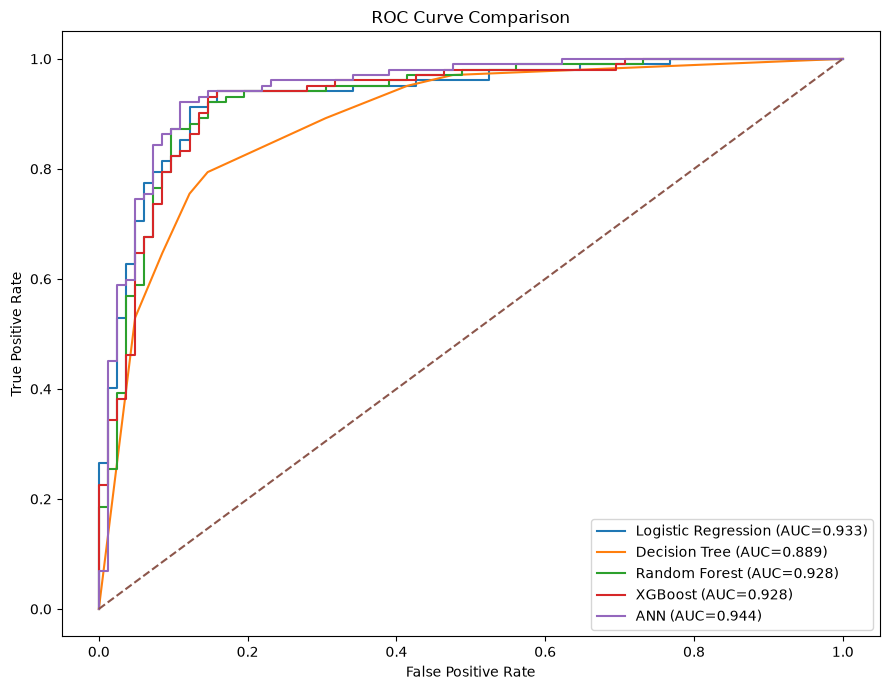

In [61]:
plt.figure(figsize=(9, 7))

for name, model in trained_models.items():

    if name == "ANN":

        probability = ann_prob

    else:

        probability = model.predict_proba(
            X_test
        )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        probability
    )

    auc = roc_auc_score(
        y_test,
        probability
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/03_roc_curves.png",
    dpi=300
)

plt.show()



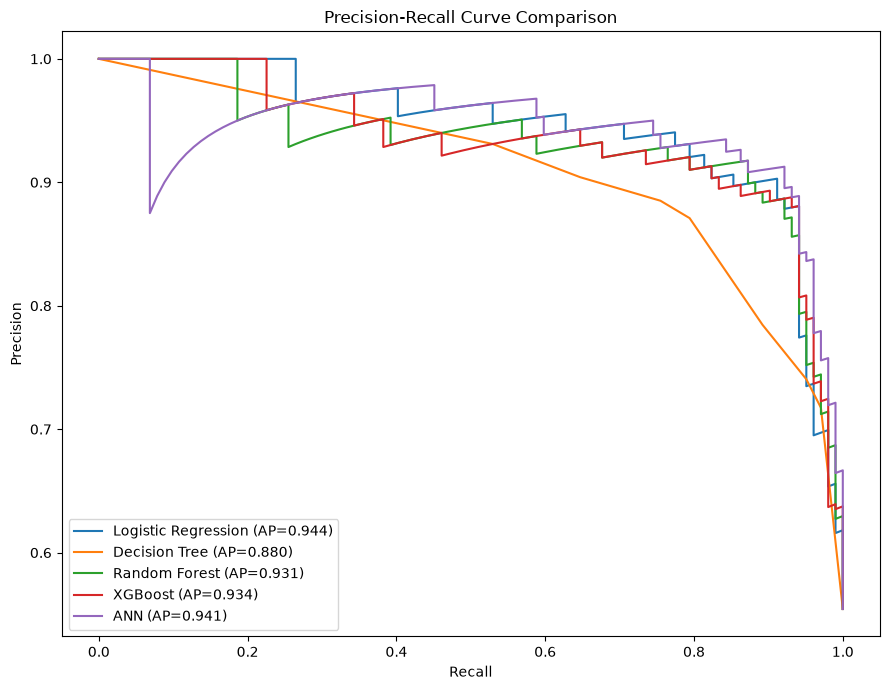

In [62]:
plt.figure(figsize=(9, 7))

for name, model in trained_models.items():

    if name == "ANN":

        probability = ann_prob

    else:

        probability = model.predict_proba(
            X_test
        )[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        probability
    )

    ap = average_precision_score(
        y_test,
        probability
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} (AP={ap:.3f})"
    )


plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curve Comparison"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/04_precision_recall_curves.png",
    dpi=300
)

plt.show()



PERMUTATION IMPORTANCE - XGBOOST
           Feature  Importance_Mean  Importance_SD
10        ST_Slope         0.100430       0.017928
2    ChestPainType         0.023852       0.010679
1              Sex         0.018209       0.006284
9          Oldpeak         0.014216       0.006795
8   ExerciseAngina         0.007018       0.003197
5        FastingBS         0.006827       0.004783
4      Cholesterol         0.003934       0.003510
3        RestingBP         0.002744       0.002443
7            MaxHR         0.002206       0.006178
0              Age         0.002021       0.002728
6       RestingECG         0.001076       0.001034


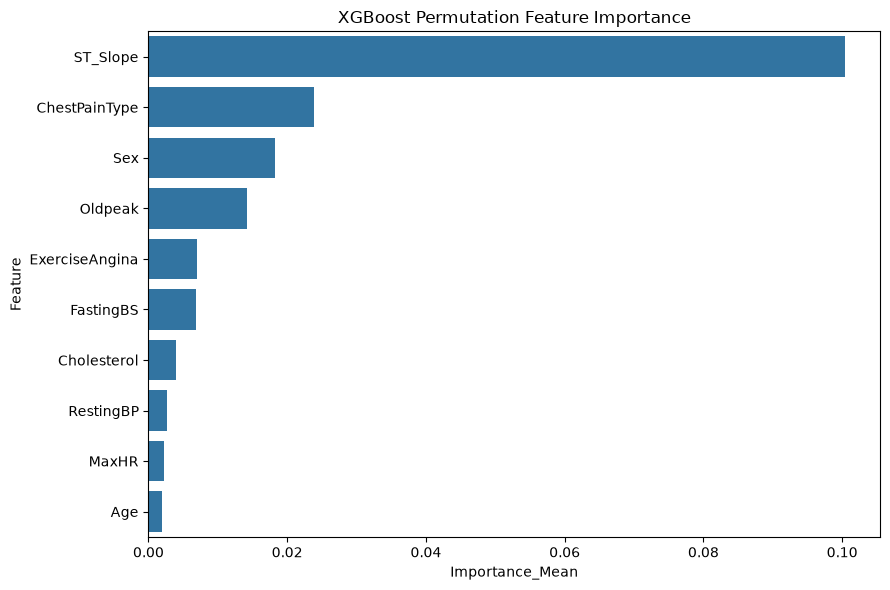

In [63]:
print("\n" + "=" * 70)
print("PERMUTATION IMPORTANCE - XGBOOST")
print("=" * 70)

xgb_model = trained_models["XGBoost"]

perm = permutation_importance(
    xgb_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_df = pd.DataFrame({

    "Feature": X_test.columns,

    "Importance_Mean":
        perm.importances_mean,

    "Importance_SD":
        perm.importances_std

}).sort_values(
    "Importance_Mean",
    ascending=False
)

print(
    importance_df.head(15)
)

importance_df.to_csv(
    f"{OUTPUT_DIR}/permutation_importance.csv",
    index=False
)


plt.figure(figsize=(9, 6))

top = importance_df.head(10)

sns.barplot(
    data=top,
    x="Importance_Mean",
    y="Feature"
)

plt.title(
    "XGBoost Permutation Feature Importance"
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/05_feature_importance.png",
    dpi=300
)

plt.show()


SHAP ANALYSIS


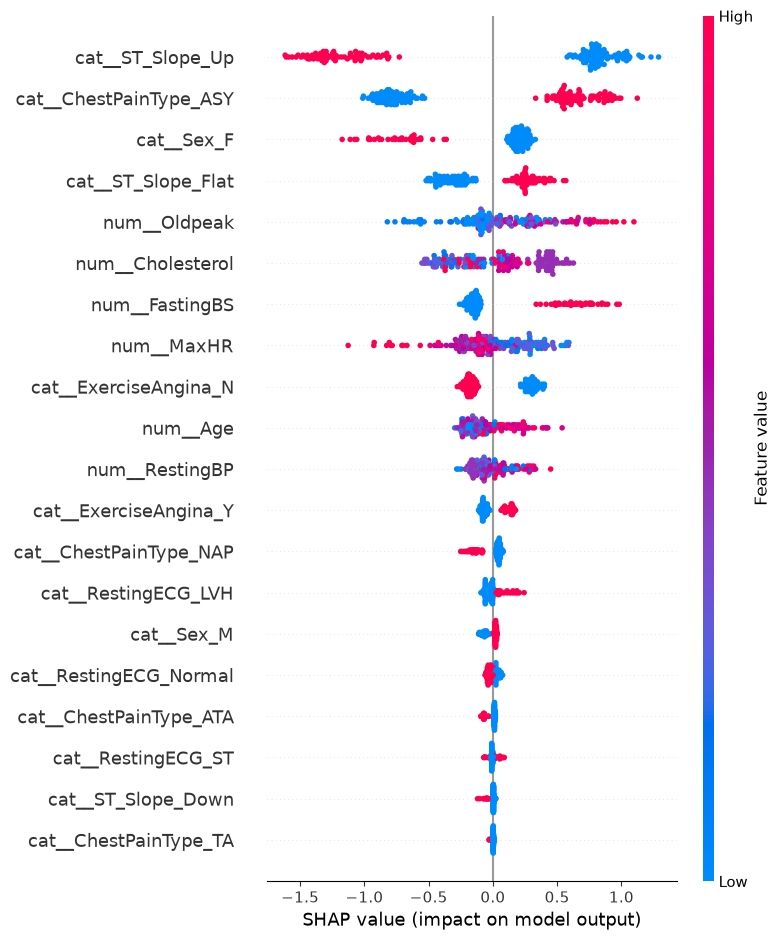

In [64]:
print("\n" + "=" * 70)
print("SHAP ANALYSIS")
print("=" * 70)

try:

    # Transform test data
    X_test_transformed = (
        xgb_model.named_steps[
            "preprocessor"
        ].transform(X_test)
    )

    if hasattr(
        X_test_transformed,
        "toarray"
    ):
        X_test_transformed = (
            X_test_transformed.toarray()
        )

    feature_names = (
        xgb_model.named_steps[
            "preprocessor"
        ].get_feature_names_out()
    )

    xgb_estimator = (
        xgb_model.named_steps[
            "model"
        ]
    )

    explainer = shap.TreeExplainer(
        xgb_estimator
    )

    shap_values = explainer(
        X_test_transformed
    )

    plt.figure()

    shap.summary_plot(
        shap_values,
        X_test_transformed,
        feature_names=feature_names,
        show=False
    )

    plt.tight_layout()

    plt.savefig(
        f"{OUTPUT_DIR}/06_xgboost_shap.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

except Exception as e:

    print(
        "SHAP analysis could not be completed:",
        e
    )

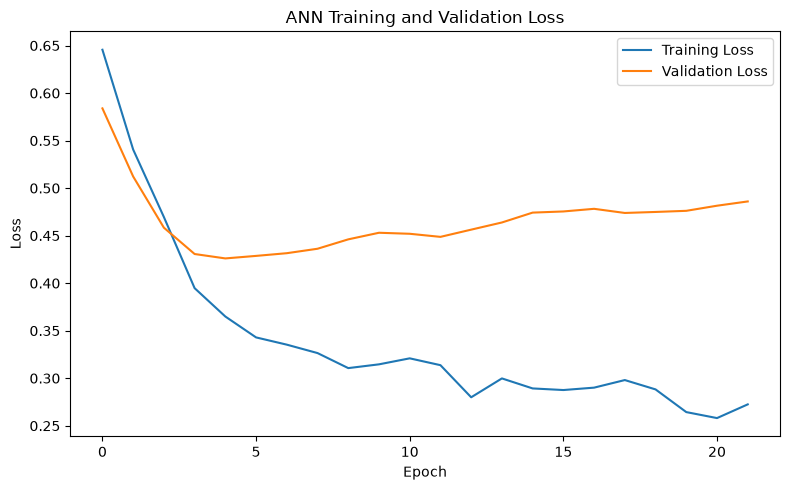

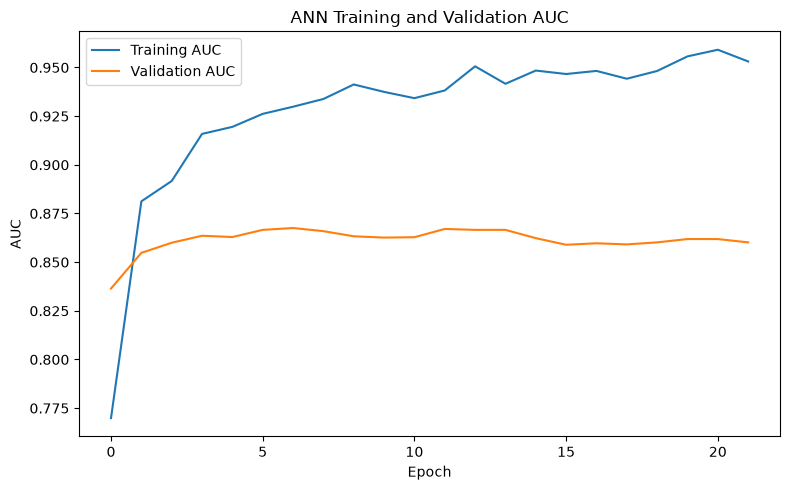

In [65]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "ANN Training and Validation Loss"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/07_ann_loss.png",
    dpi=300
)

plt.show()


plt.figure(figsize=(8, 5))

plt.plot(
    history.history["auc"],
    label="Training AUC"
)

plt.plot(
    history.history["val_auc"],
    label="Validation AUC"
)

plt.xlabel("Epoch")
plt.ylabel("AUC")

plt.title(
    "ANN Training and Validation AUC"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/08_ann_auc.png",
    dpi=300
)

plt.show()


In [66]:
print("\n" + "=" * 70)
print("SAVING MODELS")
print("=" * 70)

for name, model in trained_models.items():

    if name == "ANN":

        model.save(
            f"{OUTPUT_DIR}/ANN_model.keras"
        )

    else:

        safe_name = (
            name.lower()
            .replace(" ", "_")
        )

        joblib.dump(
            model,
            f"{OUTPUT_DIR}/{safe_name}.joblib"
        )


SAVING MODELS


In [67]:
summary = {

    "Rows": len(df),

    "Columns": len(df.columns),

    "Target": TARGET,

    "Class_0":
        int((df[TARGET] == 0).sum()),

    "Class_1":
        int((df[TARGET] == 1).sum()),

    "Duplicates":
        int(df.duplicated().sum()),

    "Missing_Cells":
        int(df.isnull().sum().sum()),

    "Random_State":
        RANDOM_STATE
}

pd.DataFrame(
    [summary]
).to_csv(
    f"{OUTPUT_DIR}/dataset_summary.csv",
    index=False
)

In [69]:
print("\n" + "=" * 70)
print("PIPELINE COMPLETE")
print(
    f"\nAll results saved in: {OUTPUT_DIR}/"
)

print("\nFinal comparison:")

print(
    results_df[
        display_columns
    ].round(4).to_string(index=False)
)

print("\nResearch pipeline completed successfully.")


PIPELINE COMPLETE

All results saved in: research_results/

Final comparison:
              Model  Accuracy  Precision  Recall     F1  ROC_AUC  PR_AUC  Specificity    NPV  Brier
Logistic Regression    0.8859     0.8857  0.9118 0.8986   0.9329  0.9440       0.8537 0.8861 0.0975
      Decision Tree    0.8207     0.8710  0.7941 0.8308   0.8890  0.8797       0.8537 0.7692 0.1295
      Random Forest    0.8804     0.8704  0.9216 0.8952   0.9277  0.9314       0.8293 0.8947 0.1047
            XGBoost    0.8859     0.8932  0.9020 0.8976   0.9275  0.9338       0.8659 0.8765 0.0979
                ANN    0.8967     0.8879  0.9314 0.9091   0.9443  0.9406       0.8537 0.9091 0.0862

Research pipeline completed successfully.
